In [1]:
import os
import random
import time
import tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statistics import mean

1️⃣ Fibonacci – Recursive

In [23]:
def fib_recursive(n):
    if n <= 1:
        return n
    return fib_recursive(n - 1) + fib_recursive(n - 2)
n = 10
print("Fibonacci Recursive(", n, ") =", fib_recursive(n))


Fibonacci Recursive( 10 ) = 55


Complexity:

Best: O(n) (very small n)

Average/Worst: O(2ⁿ) (exponential growth)

Space: O(n) (recursion stack)
Suitability & Trade-offs:

Easy to implement, but extremely slow for large n.

Stack overflow risk for large recursion depth.

Not suitable for large input sizes.

In [ ]:
2️⃣ Fibonacci – Dynamic Programming (Iterative)

In [24]:
def fib_dp(n):
    if n <= 1:
        return n
    a, b = 0, 1
    for _ in range(2, n+1):
        a, b = b, a + b
    return b

n = 10
print("Fibonacci DP(", n, ") =", fib_dp(n))


Fibonacci DP( 10 ) = 55


omplexity:

Best/Average/Worst: O(n)

Space: O(1)
Suitability & Trade-offs:

Very efficient and stack-safe.

Suitable for large Fibonacci computations.

Slightly more code but avoids recursion risk.

3️⃣ Merge Sort

In [31]:
def merge_sort(arr):
    if len(arr) <= 1:
        return arr
    mid = len(arr)//2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    i = j = 0
    result = []
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i]); i += 1
        else:
            result.append(right[j]); j += 1
    result.extend(left[i:])
    result.extend(right[j:])
    return result

arr = [5, 3, 8, 4, 2]
print("Before:", arr)
print("After:", merge_sort(arr))


Before: [5, 3, 8, 4, 2]
After: [2, 3, 4, 5, 8]


Complexity:

Best/Average/Worst: O(n log n)

Space: O(n) (extra list)
Suitability & Trade-offs:

Stable, consistent performance.

Needs extra space, not ideal for embedded systems.

4️⃣ Quick Sort

In [30]:
def quick_sort(arr):
    if len(arr) <= 1:
        return arr
    pivot = arr[len(arr)//2]
    left = [x for x in arr if x < pivot]
    mid = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]
    return quick_sort(left) + mid + quick_sort(right)

arr = [7, 1, 5, 9, 2]
print("Before:", arr)
print("After:", quick_sort(arr))


Before: [7, 1, 5, 9, 2]
After: [1, 2, 5, 7, 9]


Complexity:

Best/Average: O(n log n)

Worst: O(n²) (poor pivot choice)

Space: O(log n) (recursion stack)
Suitability & Trade-offs:

Fast and popular, but unstable in worst case.

Recursion depth may cause stack overflow for bad pivots.

5️⃣ Insertion Sort

In [29]:
def insertion_sort(arr):
    a = arr.copy()
    for i in range(1, len(a)):
        key = a[i]
        j = i - 1
        while j >= 0 and a[j] > key:
            a[j + 1] = a[j]
            j -= 1
        a[j + 1] = key
    return a

arr = [5, 2, 4, 1]
print("Before:", arr)
print("After:", insertion_sort(arr))


Before: [5, 2, 4, 1]
After: [1, 2, 4, 5]


Complexity:

Best: O(n)

Average/Worst: O(n²)

Space: O(1)
Suitability & Trade-offs:

Simple and stable for small lists.

Very slow for large input.

6️⃣ Bubble Sort

In [28]:
def bubble_sort(arr):
    a = arr.copy()
    n = len(a)
    for i in range(n):
        for j in range(0, n-i-1):
            if a[j] > a[j+1]:
                a[j], a[j+1] = a[j+1], a[j]
    return a

arr = [4, 2, 7, 1]
print("Before:", arr)
print("After:", bubble_sort(arr))


Before: [4, 2, 7, 1]
After: [1, 2, 4, 7]


Complexity:

Best: O(n)

Average/Worst: O(n²)

Space: O(1)
Suitability & Trade-offs:

Easy to understand, but inefficient for large datasets.

Best used for educational demonstration.

7️⃣ Selection Sort

In [27]:
def selection_sort(arr):
    a = arr.copy()
    n = len(a)
    for i in range(n):
        min_idx = i
        for j in range(i+1, n):
            if a[j] < a[min_idx]:
                min_idx = j
        a[i], a[min_idx] = a[min_idx], a[i]
    return a

arr = [9, 4, 3, 1]
print("Before:", arr)
print("After:", selection_sort(arr))


Before: [9, 4, 3, 1]
After: [1, 3, 4, 9]


Complexity:

Best/Average/Worst: O(n²)

Space: O(1)
Suitability & Trade-offs:

Minimal memory use, but poor performance.

Good for small arrays.

8️⃣ Binary Search

In [26]:
def binary_search(arr, x):
    low, high = 0, len(arr) - 1
    while low <= high:
        mid = (low + high) // 2
        if arr[mid] == x:
            return mid
        elif arr[mid] < x:
            low = mid + 1
        else:
            high = mid - 1
    return -1

arr = [1, 3, 5, 7, 9]
x = 7
print("Array:", arr)
print("Element", x, "found at index:", binary_search(arr, x))


Array: [1, 3, 5, 7, 9]
Element 7 found at index: 3


Complexity:

Best: O(1)

Average/Worst: O(log n)

Space: O(1)
Suitability & Trade-offs:

Extremely efficient for sorted data.

Requires pre-sorted input.

# Performance Measurement & Plotting




In [33]:
!pip install memory_profiler


Merge Sort | n=100 | time=0.0003s | mem=194.08MB
Merge Sort | n=200 | time=0.0005s | mem=194.08MB
Merge Sort | n=500 | time=0.0040s | mem=194.08MB
Merge Sort | n=1000 | time=0.0064s | mem=194.08MB
Merge Sort | n=2000 | time=0.0092s | mem=194.08MB
Quick Sort | n=100 | time=0.0002s | mem=194.08MB
Quick Sort | n=200 | time=0.0005s | mem=194.08MB
Quick Sort | n=500 | time=0.0015s | mem=194.08MB
Quick Sort | n=1000 | time=0.0024s | mem=194.08MB
Quick Sort | n=2000 | time=0.0039s | mem=194.08MB
Insertion Sort | n=100 | time=0.0002s | mem=194.08MB
Insertion Sort | n=200 | time=0.0012s | mem=194.08MB
Insertion Sort | n=500 | time=0.0072s | mem=194.08MB
Insertion Sort | n=1000 | time=0.0229s | mem=194.08MB
Insertion Sort | n=2000 | time=0.0984s | mem=194.08MB
Bubble Sort | n=100 | time=0.0004s | mem=194.08MB
Bubble Sort | n=200 | time=0.0045s | mem=194.08MB
Bubble Sort | n=500 | time=0.0124s | mem=194.08MB
Bubble Sort | n=1000 | time=0.0489s | mem=194.08MB
Bubble Sort | n=2000 | time=0.2321s | 

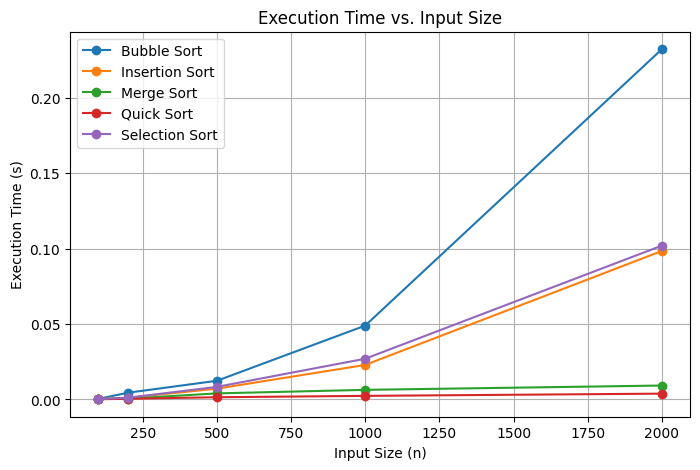

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from memory_profiler import memory_usage
import time, random
import pandas as pd

def merge_sort(arr):
    if len(arr) <= 1:
        return arr
    mid = len(arr)//2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    i = j = 0
    merged = []
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            merged.append(left[i]); i+=1
        else:
            merged.append(right[j]); j+=1
    merged.extend(left[i:]); merged.extend(right[j:])
    return merged

def quick_sort(arr):
    if len(arr) <= 1:
        return arr
    pivot = arr[len(arr)//2]
    left = [x for x in arr if x < pivot]
    mid = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]
    return quick_sort(left) + mid + quick_sort(right)

def insertion_sort(arr):
    a = arr.copy()
    for i in range(1, len(a)):
        key = a[i]
        j = i-1
        while j >= 0 and a[j] > key:
            a[j+1] = a[j]
            j -= 1
        a[j+1] = key
    return a

def bubble_sort(arr):
    a = arr.copy()
    n = len(a)
    for i in range(n):
        for j in range(0, n-i-1):
            if a[j] > a[j+1]:
                a[j], a[j+1] = a[j+1], a[j]
    return a

def selection_sort(arr):
    a = arr.copy()
    n = len(a)
    for i in range(n):
        min_idx = i
        for j in range(i+1, n):
            if a[j] < a[min_idx]:
                min_idx = j
        a[i], a[min_idx] = a[min_idx], a[i]
    return a

algorithms = {
    "Merge Sort": merge_sort,
    "Quick Sort": quick_sort,
    "Insertion Sort": insertion_sort,
    "Bubble Sort": bubble_sort,
    "Selection Sort": selection_sort
}

sizes = [100, 200, 500, 1000, 2000]
results = []

for name, func in algorithms.items():
    for n in sizes:
        arr = [random.randint(0, 10000) for _ in range(n)]

        start = time.time()
        func(arr)
        end = time.time()
        exec_time = end - start
        mem_used = max(memory_usage((func, (arr,), {})))

        results.append([name, n, exec_time, mem_used])
        print(f"{name} | n={n} | time={exec_time:.4f}s | mem={mem_used:.2f}MB")

df = pd.DataFrame(results, columns=["Algorithm", "Input_Size", "Time_s", "Memory_MB"])

plt.figure(figsize=(8,5))
for algo, group in df.groupby("Algorithm"):
    plt.plot(group["Input_Size"], group["Time_s"], marker="o", label=algo)
plt.title('Execution Time vs. Input Size')
plt.xlabel('Input Size (n)')
plt.ylabel('Execution Time (s)')
plt.legend()
plt.grid(True)
plt.show()